In [12]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lotka-Volterra

In [14]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dts = np.logspace(-2, 0, 11).tolist()
noise_levels = np.logspace(-3, 0, 10).tolist()

t_span = (0, 50)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 0,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dts, 't_span_train': t_span,
    'train_interpolation_dt': None,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config)

rows are noise_level. there are 10 rows.
columns are dt_train. there are 11 columns.
step 1 of 10


100%|██████████| 11/11 [00:03<00:00,  2.85it/s]


step 2 of 10


100%|██████████| 11/11 [00:03<00:00,  2.95it/s]


step 3 of 10


...

100%|██████████| 11/11 [00:05<00:00,  2.17it/s]


step 9 of 10


100%|██████████| 11/11 [00:05<00:00,  2.14it/s]


step 10 of 10


100%|██████████| 11/11 [00:04<00:00,  2.55it/s]


rows are noise_level. there are 10 rows.
columns are dt_train. there are 11 columns.


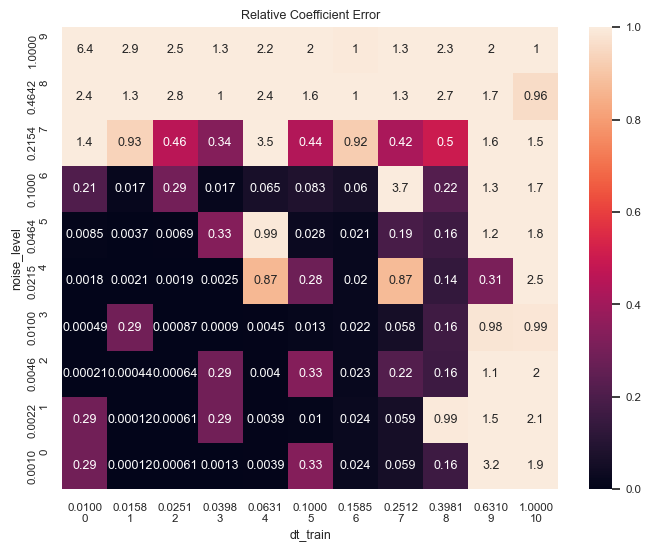

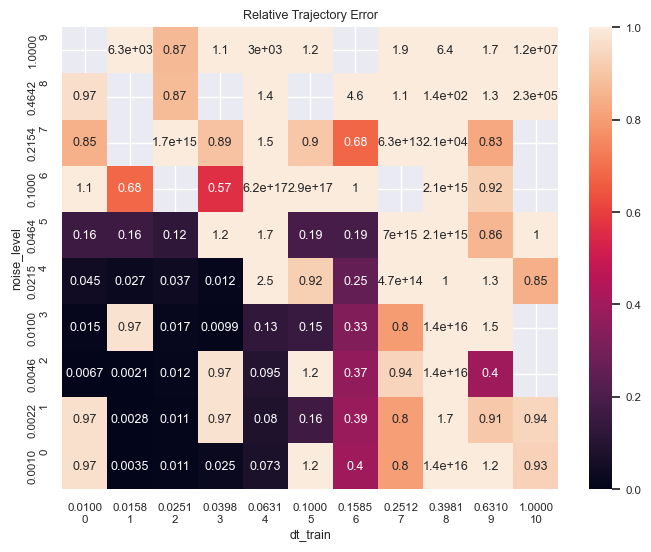

In [15]:
plot_heatmaps(experiment_config, results)

In [23]:
default_params['lotka_volterra']

(1.1, 0.4, 0.4, 0.1)

### Both of these systems have the same trajectory error. But one is way more accurate than the other! We need a better error metric!

x0' = + 1.08838 x0 + -0.39454 x0 x1 
x1' = + -0.38449 x1 + 0.09605 x0 x1 
x0' = + 0.91396 x0 + 0.52906 x1 + -0.33045 x0 x1 + -0.07675 x1^2 
x1' = + -0.90252 1 + 0.06599 x0 x1 


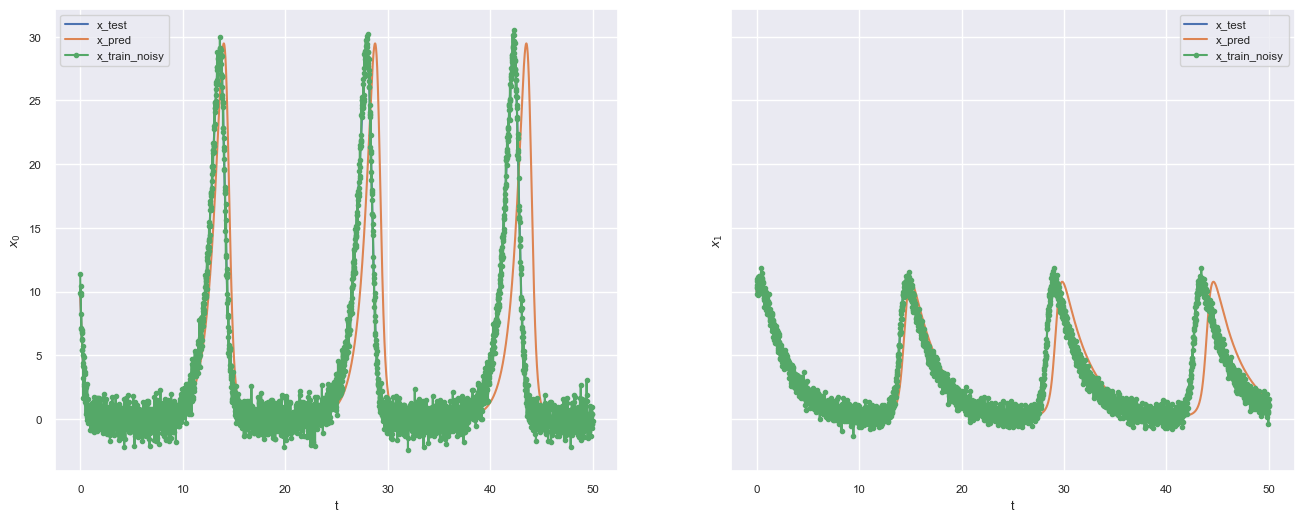

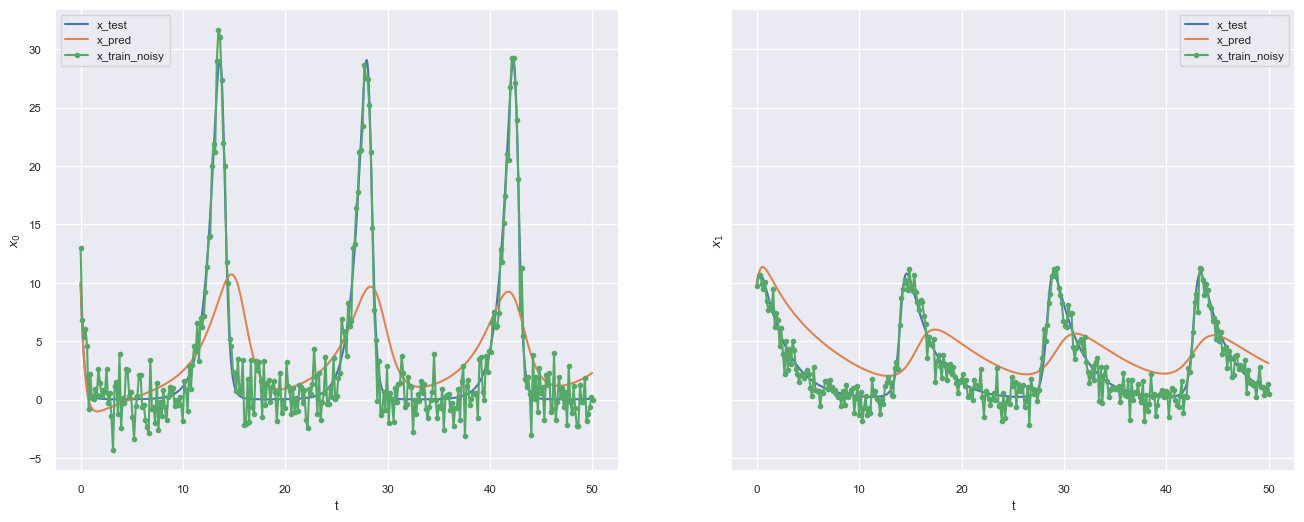

In [27]:
display_single_result(experiment_config, results, 1, 6, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])
display_single_result(experiment_config, results, 6, 7, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

# Van der Pol

In [19]:
# van_der_pol_oscillator_rhs = generate_van_der_pol_oscillator_rhs(*default_params['van_der_pol_oscillator'])
# true_coeffs = generate_van_der_pol_oscillator_true_coefficients(*default_params['van_der_pol_oscillator'])
# x0 = default_x0['van_der_pol_oscillator']

# dts = np.logspace(-2, 0, 11).tolist()
# noise_levels = np.logspace(-3, 0, 10).tolist()

# t_span = (0, 50)

# # if a parameter is a list, the experiment will be run for each combination of the parameters
# # if a parameter is not a list, the same value will be used for all experiments
# # the first list will be the rows and the second list will be the columns
# experiment_config2 = {
#     # define fixed parameters
#     'rhs': van_der_pol_oscillator_rhs,
#     'derivative_approximation': dxdt_finite_difference,
#     't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
#     'np_seed': 0,
#     'true_coeffs': true_coeffs,
#     # define parameters that can be lists
#     'x0': x0, 'noise_level': noise_levels,
#     't_eval_train': None, 'dt_train': dts, 't_span_train': t_span,
#     'train_interpolation_dt': None,
#     'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0,
# }

# results2 = run_experiment(experiment_config2)

In [18]:
# plot_heatmaps(experiment_config2, results2)

In [17]:
# display_single_result(experiment_config2, results2, 3, 6, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])